# **Corpus Describtion:**
IMDB Dataset Movie Reviews (Internet Movie Database )

The dataset consits:
*   50,000 movie reviews.
*   two columns (Reviews"Text", Sentiment(label, "Positive, Negative") ).
*  balanced (50% Positive, 50% Negative).


Dataset path:
/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv

---






In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report,recall_score, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import  word_tokenize
nltk.download('punkt_tab')
nltk.download('punkt')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [9]:
df = pd.read_csv(r"/content/IMDB Dataset.csv")

# Preview the first rows of the dataset
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [10]:
#data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


# **Data Cleaning**

In [11]:
print("number of samples:", df.shape[0])
print("number of feutures:", df.shape[1])

number of samples: 50000
number of feutures: 2


In [12]:
#print columns name
print(df.columns)

Index(['review', 'sentiment'], dtype='object')


In [13]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [14]:
df.drop_duplicates(inplace=True)

In [15]:
print(df.shape)

(49582, 2)


In [16]:
print(df.isnull().sum()) # Calculate the missing value in each column

review       0
sentiment    0
dtype: int64


In [17]:
#Encode labels
df['sentiment'].replace({'positive' : 1, 'negative' : 0}, inplace =True)
df.head(10)

/tmp/ipykernel_12076/3971838704.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sentiment'].replace({'positive' : 1, 'negative' : 0}, inplace =True)
/tmp/ipykernel_12076/3971838704.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sentiment'].replace({'positive' : 1, 'negative' : 0}, i

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1
5,"Probably my all-time favorite movie, a story o...",1
6,I sure would like to see a resurrection of a u...,1
7,"This show was an amazing, fresh & innovative i...",0
8,Encouraged by the positive comments about this...,0
9,If you like original gut wrenching laughter yo...,1


# **Text preprocessing**

In [18]:
#Convert to lower
df['review'] = df['review'].str.lower()
df['review']

,review
0,one of the other reviewers has mentioned that ...
1,a wonderful little production. <br /><br />the...
2,i thought this was a wonderful way to spend ti...
3,basically there's a family where a little boy ...
4,"petter mattei's ""love in the time of money"" is..."
...,...
49995,i thought this movie did a down right good job...
49996,"bad plot, bad dialogue, bad acting, idiotic di..."
49997,i am a catholic taught in parochial elementary...
49998,i'm going to have to disagree with the previou...


In [19]:
#remove punctuation marks & digits
df['review'] = df['review'].apply(lambda x: re.sub(r'<.*?>', '', x))
df['review'] = df['review'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))
df['review']


,review
0,one of the other reviewers has mentioned that ...
1,a wonderful little production the filming tech...
2,i thought this was a wonderful way to spend ti...
3,basically theres a family where a little boy j...
4,petter matteis love in the time of money is a ...
...,...
49995,i thought this movie did a down right good job...
49996,bad plot bad dialogue bad acting idiotic direc...
49997,i am a catholic taught in parochial elementary...
49998,im going to have to disagree with the previous...


In [20]:
#tokenization
def token (text):
       text = nltk.word_tokenize(text)
       return text


df['review'] = df['review'].map(token) # take arg(function) and applies to all values
df['review']

,review
0,"[one, of, the, other, reviewers, has, mentione..."
1,"[a, wonderful, little, production, the, filmin..."
2,"[i, thought, this, was, a, wonderful, way, to,..."
3,"[basically, theres, a, family, where, a, littl..."
4,"[petter, matteis, love, in, the, time, of, mon..."
...,...
49995,"[i, thought, this, movie, did, a, down, right,..."
49996,"[bad, plot, bad, dialogue, bad, acting, idioti..."
49997,"[i, am, a, catholic, taught, in, parochial, el..."
49998,"[im, going, to, have, to, disagree, with, the,..."


In [21]:
#stop words
stop_words=set(stopwords.words('english'))
print(stop_words)

{'same', 'herself', "we'll", 've', 'his', 're', 'be', "hadn't", "we'd", "haven't", "doesn't", 'doesn', 'y', "i'd", "you'd", 'nor', 'that', 'until', 'she', 'as', "he's", 'other', 'them', 'any', "wouldn't", 'yourselves', 'up', "needn't", 'don', 'aren', 'in', 'here', 'myself', 'during', 'when', 'shan', 'under', 'your', 'or', "wasn't", 'ours', "don't", 'm', 'to', 'who', 'hadn', "she'd", 'own', 'ourselves', 'only', 'of', "it'll", 'an', 'all', 'himself', 'i', 'above', 'further', 'hasn', "we've", 'their', 'this', 'does', 'and', 'him', 'you', 'its', 'by', "you'll", "mustn't", "they're", "isn't", 'won', 'because', 'not', 'ain', 'whom', 'needn', 'they', 'then', 'off', 'yourself', 'down', 'such', 'couldn', "i've", 'mustn', 'there', 'how', 'too', 'being', "i'm", 'most', "didn't", 'about', 'both', "shouldn't", 'has', 'what', "they'd", 'after', "shan't", 'ma', "weren't", "it's", 'was', "should've", 'each', 'didn', 'these', 'for', "you've", 'those', 'haven', 'through', 'than', 'below', 'which', 'hers

In [22]:
#remove stop words
#It helps us to delete unimportant words.
df['review_no_sw'] = df ['review'].map(lambda x:([word for word in x if word not in stop_words])) # Mapping takes function using lambda and join is used to return text to string

print(df['review'].head())
print(df['review_no_sw'].head())

0    [one, of, the, other, reviewers, has, mentione...
1    [a, wonderful, little, production, the, filmin...
2    [i, thought, this, was, a, wonderful, way, to,...
3    [basically, theres, a, family, where, a, littl...
4    [petter, matteis, love, in, the, time, of, mon...
Name: review, dtype: object
0    [one, reviewers, mentioned, watching, oz, epis...
1    [wonderful, little, production, filming, techn...
2    [thought, wonderful, way, spend, time, hot, su...
3    [basically, theres, family, little, boy, jake,...
4    [petter, matteis, love, time, money, visually,...
Name: review_no_sw, dtype: object


In [23]:
#POS
from nltk.corpus import wordnet
nltk.download('averaged_perceptron_tagger_eng')

df['review_pos'] = df['review'].apply(pos_tag)
df['review_no_sw_pos'] = df['review_no_sw'].apply(pos_tag)
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [24]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [25]:
#Lemmatization
lemmatizer = WordNetLemmatizer()

def lem_pos (tokens):
  tokens = tokens.apply(lambda x:' '.join([lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in x]))
  return tokens

df['review_pos'] = lem_pos(df['review_pos'])
df['review_no_sw_pos'] = lem_pos(df['review_no_sw_pos'])

print(df['review_pos'].head())
print(df['review_no_sw_pos'].head())

0    one of the other reviewer have mention that af...
1    a wonderful little production the filming tech...
2    i think this be a wonderful way to spend time ...
3    basically theres a family where a little boy j...
4    petter matteis love in the time of money be a ...
Name: review_pos, dtype: object
0    one reviewer mention watch oz episode youll ho...
1    wonderful little production film technique una...
2    think wonderful way spend time hot summer week...
3    basically there family little boy jake think t...
4    petter matteis love time money visually stunni...
Name: review_no_sw_pos, dtype: object


# **Model Training**

In [26]:
X_train, X_test, y_train, y_test = train_test_split(df['review_pos'], df['sentiment'], test_size=0.2, random_state=42)
X_train_no_sw, X_test_no_sw, y_train_no_sw, y_test_no_sw = train_test_split(df['review_no_sw_pos'], df['sentiment'], test_size=0.2, random_state=42)

print(X_train.head())
print("\n", X_train_no_sw.head())

7837     i really like the movie the emporers new groov...
4814     i decide to watch this movie because it have b...
35458    it very hard to say just what be go on with th...
3446     this scifi adventure be not the best and by no...
24478    around the late s animator don bluth frustrate...
Name: review_pos, dtype: object

 7837     really liked movie emporers new groove watchin...
4814     decide watch movie note scary movie ever thats...
35458    hard say go lady shanghai film could without s...
3446     scifi adventure best mean bad agree statement ...
24478    around late animator bluth frustrate output co...
Name: review_no_sw_pos, dtype: object


# **Text vectorization (Term Frequency-Inverse Document Frequency):**

In [27]:
# Initialize the TF-IDF Vectorizer
tfidf_sw = TfidfVectorizer(max_features = 5000)
tfidf_no_sw = TfidfVectorizer(max_features = 5000)

# Fit and transform the data
X_train_tfidf_sw = tfidf_sw.fit_transform(X_train)
X_train_tfidf_no_sw = tfidf_no_sw.fit_transform(X_train_no_sw)

X_test_tfidf_sw = tfidf_sw.transform(X_test)
X_test_tfidf_no_sw = tfidf_no_sw.transform(X_test_no_sw)


print('With Stop Words:')
print('Train TF-IDF: ', X_train_tfidf_sw.shape)
print('Test TF-IDF: ', X_test_tfidf_sw.shape)

print('Without Stop Words:')
print('Train TF-IDF: ', X_train_tfidf_no_sw.shape)
print('Test TF-IDF: ', X_test_tfidf_no_sw.shape)

With Stop Words:
Train TF-IDF:  (39665, 5000)
Test TF-IDF:  (9917, 5000)
Without Stop Words:
Train TF-IDF:  (39665, 5000)
Test TF-IDF:  (9917, 5000)


# Logistic Regression

In [28]:
#Train Logistic Regression model (without stop words)
logistic_classifier = LogisticRegression(max_iter=100,random_state=42)
logistic_classifier.fit(X_train_tfidf_no_sw, y_train_no_sw)

LogisticRegression(random_state=42)

Accuracy : 88.02%

Classification Report : 
               precision    recall  f1-score   support

           0       0.89      0.87      0.88      4939
           1       0.87      0.89      0.88      4978

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



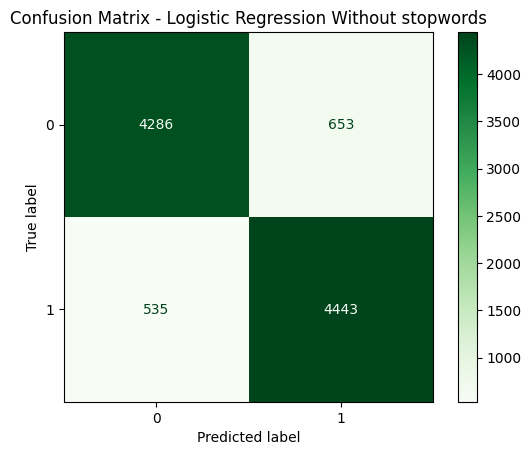

In [29]:
#Predict on test data
y_pred_no_sw = logistic_classifier.predict(X_test_tfidf_no_sw)
score = accuracy_score(y_test_no_sw, y_pred_no_sw) *100
print(f'Accuracy : {score:.2f}%' )
print()
print('Classification Report : \n', classification_report(y_test_no_sw, y_pred_no_sw))

#Confusion Matrix
cm = confusion_matrix(y_test_no_sw, y_pred_no_sw)
ConfusionMatrixDisplay(cm).plot(cmap='Greens')
plt.title('Confusion Matrix - Logistic Regression Without stopwords')
plt.show()

In [30]:
#Train Logistic Regression model (with stop words)
logistic_classifier = LogisticRegression(max_iter=100, random_state=42)
logistic_classifier.fit(X_train_tfidf_sw, y_train)

LogisticRegression(random_state=42)

Accuracy : 88.23%

Classification Report : 
               precision    recall  f1-score   support

           0       0.89      0.87      0.88      4939
           1       0.87      0.90      0.88      4978

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



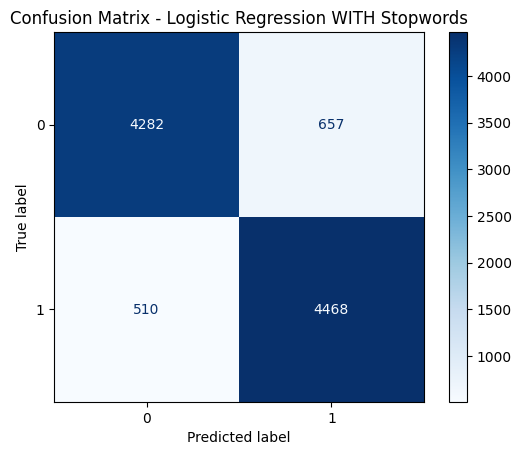

In [31]:
#Predict on test data
y_pred_sw = logistic_classifier.predict(X_test_tfidf_sw)
score = accuracy_score(y_test, y_pred_sw) * 100
print(f"Accuracy : {score:.2f}%")
print()
print('Classification Report : \n', classification_report(y_test, y_pred_sw))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_sw)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression WITH Stopwords')
plt.show()

# SVM Model

In [32]:
#SVM MODEL (with stop words)
from sklearn.svm import LinearSVC

classifier_linear = LinearSVC()
classifier_linear.fit(X_train_tfidf_sw, y_train)

LinearSVC()

Accuracy : 87.82%
Classification Report : 
               precision    recall  f1-score   support

           0       0.89      0.87      0.88      4939
           1       0.87      0.89      0.88      4978

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



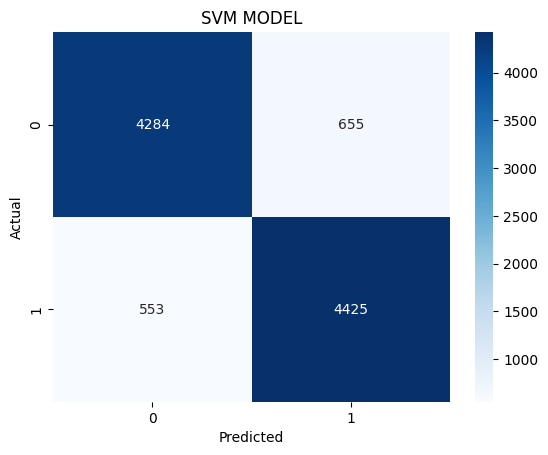

In [33]:
#Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_sw = classifier_linear.predict(X_test_tfidf_sw)
score1 = accuracy_score(y_test, y_pred_sw) *100
print(f'Accuracy : {score1:.2f}%' )
print('Classification Report : \n', classification_report(y_test, y_pred_sw))
cm = confusion_matrix(y_test, y_pred_sw)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM MODEL')
plt.show()

In [34]:
#SVM MODEL (without stop words)
# Initialize Linear SVM model
model = LinearSVC()

# Train the model
model.fit(X_train_tfidf_no_sw, y_train_no_sw)

LinearSVC()

Accuracy: 87.62%
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      4939
           1       0.87      0.89      0.88      4978

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917

[[4266  673]
 [ 555 4423]]


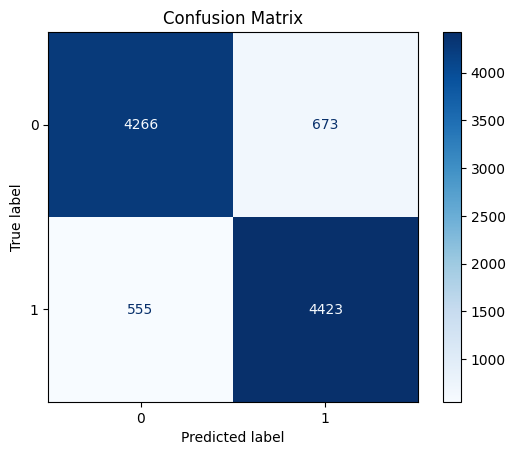

In [35]:
# Predict sentiment labels
y_pred_no_sw = model.predict(X_test_tfidf_no_sw)

# Calculate and print accuracy
accuracy = accuracy_score(y_test_no_sw, y_pred_no_sw)*100
print(f"Accuracy: {accuracy:.2f}%")

# Display classification report
print(classification_report(y_test_no_sw, y_pred_no_sw))

# Generate confusion matrix
cm = confusion_matrix(y_test_no_sw, y_pred_no_sw)

print(cm)

# Display confusion matrix visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")

plt.show()

# Compare between Traditional (LR, SVM) and LLMs

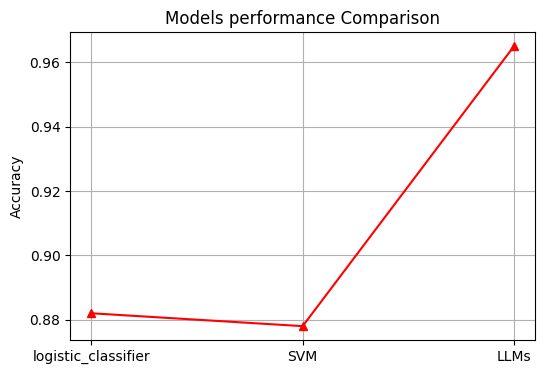

In [36]:
models=['logistic_classifier','SVM','LLMs']
Accuracy = [0.882,0.878,0.965]
plt.figure(figsize=(6,4))
plt.plot(models, Accuracy, marker='^',color='red')
plt.ylabel("Accuracy")
plt.title("Models performance Comparison")
plt.grid(True)
plt.show()